# 4. Final results and report figures

This notebook collects the saved results from the reconstruction, improvement, and multi-horizon experiments. It does **not** train any model or make a new model-selection decision. Its purpose is to produce the final comparison tables and figures used in the report.

## 1. Setup

The experiment CSV files are the numerical source of truth. Internal development labels are converted here to meaningful names for presentation.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULT_ROOT = PROJECT_ROOT / "results" / "dlinear" / "weather"
MAIN_RESULT_ROOT = RESULT_ROOT / "horizon_096"
FIGURE_ROOT = PROJECT_ROOT / "outputs" / "report_figures"
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

DISPLAY_NAMES = {
    "DLinear": "DLinear reconstruction",
    "V1 static multiscale": "Static per-variable multiscale DLinear",
    "V2A dynamic multiscale": "Dynamic per-variable multiscale DLinear",
    "Dynamic multiscale V2A": "Dynamic per-variable multiscale DLinear",
}
FIGURE_NAMES = {
    "DLinear": "DLinear",
    "V1 static multiscale": "Static multiscale",
    "V2A dynamic multiscale": "Dynamic multiscale",
    "Dynamic multiscale V2A": "Dynamic multiscale",
}

reconstruction = pd.read_csv(MAIN_RESULT_ROOT / "reconstruction_by_seed.csv")
validation = pd.read_csv(MAIN_RESULT_ROOT / "validation_by_seed.csv")
test_by_seed = pd.read_csv(MAIN_RESULT_ROOT / "test_by_seed.csv")
test_summary = pd.read_csv(MAIN_RESULT_ROOT / "test_summary.csv")
multihorizon = pd.read_csv(RESULT_ROOT / "multihorizon_by_seed.csv")

print("Loaded saved results. Figures will be written to:", FIGURE_ROOT)

Loaded saved results. Figures will be written to: d:\Projects\time-series-analysis-final-project\outputs\report_figures


## 2. Paper result and reconstruction

The official experiment uses one run with seed 2021, so the direct comparison uses our seed-2021 reconstruction. A negative relative difference means that our error is lower than the value reported in the paper.

In [2]:
paper_metrics = {"MSE": 0.176, "MAE": 0.237}
seed_2021 = reconstruction.loc[reconstruction["seed"] == 2021].iloc[0]

reconstruction_comparison = pd.DataFrame(
    {
        "Metric": ["MSE", "MAE"],
        "Paper DLinear": [paper_metrics["MSE"], paper_metrics["MAE"]],
        "Our reconstruction": [seed_2021["test_mse"], seed_2021["test_mae"]],
    }
)
reconstruction_comparison["Relative difference (%)"] = 100 * (
    reconstruction_comparison["Our reconstruction"]
    - reconstruction_comparison["Paper DLinear"]
) / reconstruction_comparison["Paper DLinear"]
reconstruction_comparison.round(4)

,Metric,Paper DLinear,Our reconstruction,Relative difference (%)
0,MSE,0.176,0.1742,-1.0196
1,MAE,0.237,0.2333,-1.5494


## 3. Main 96-step comparison

The following table reports mean and sample standard deviation over seeds 2021, 2022, and 2023. The seasonal-naive baseline has no learned parameters and no random seed.

In [3]:
main_table = test_summary.copy()
main_table["Model"] = main_table["model"].map(DISPLAY_NAMES)
main_table["MSE (mean ± SD)"] = main_table.apply(
    lambda row: f'{row["test_mse_mean"]:.5f} ± {row["test_mse_std"]:.5f}', axis=1
)
main_table["MAE (mean ± SD)"] = main_table.apply(
    lambda row: f'{row["test_mae_mean"]:.5f} ± {row["test_mae_std"]:.5f}', axis=1
)
parameters = (
    test_by_seed.assign(Model=test_by_seed["model"].map(DISPLAY_NAMES))
    .groupby("Model")["parameters"]
    .first()
)
main_table["Parameters"] = main_table["Model"].map(parameters)
main_table[["Model", "MSE (mean ± SD)", "MAE (mean ± SD)", "Parameters", "mse_wins_vs_dlinear", "mae_wins_vs_dlinear"]].rename(
    columns={
        "mse_wins_vs_dlinear": "MSE wins vs DLinear",
        "mae_wins_vs_dlinear": "MAE wins vs DLinear",
    }
)

,Model,MSE (mean ± SD),MAE (mean ± SD),Parameters,MSE wins vs DLinear,MAE wins vs DLinear
0,DLinear reconstruction,0.17464 ± 0.00052,0.23486 ± 0.00174,64704,NaN,NaN
1,Static per-variable multiscale DLinear,0.16739 ± 0.00044,0.22910 ± 0.00114,64767,3/3,3/3
2,Dynamic per-variable multiscale DLinear,0.16540 ± 0.00045,0.22492 ± 0.00137,64834,3/3,3/3


In [4]:
seasonal_naive = pd.DataFrame(
    [{"Model": "Seasonal naive", "MSE": 0.3167066, "MAE": 0.2879560, "Parameters": 0}]
)
seasonal_naive["RMSE"] = np.sqrt(seasonal_naive["MSE"])
seasonal_naive.round(6)

,Model,MSE,MAE,Parameters,RMSE
0,Seasonal naive,0.316707,0.287956,0,0.562767


## 4. Paired improvements and parameter cost

Pairing by seed makes the comparison less sensitive to random initialization. Positive percentages mean that the improved model has lower error than DLinear.

In [5]:
paired_main = test_by_seed.pivot(index="seed", columns="model", values=["test_mse", "test_mae"])
dlinear_mse = paired_main[("test_mse", "DLinear")]
dlinear_mae = paired_main[("test_mae", "DLinear")]

relative_rows = []
for internal_name in ("V1 static multiscale", "V2A dynamic multiscale"):
    model_mse = paired_main[("test_mse", internal_name)]
    model_mae = paired_main[("test_mae", internal_name)]
    relative_rows.append(
        {
            "Model": DISPLAY_NAMES[internal_name],
            "MSE reduction (%)": (100 * (dlinear_mse - model_mse) / dlinear_mse).mean(),
            "MAE reduction (%)": (100 * (dlinear_mae - model_mae) / dlinear_mae).mean(),
            "MSE wins": f"{int((model_mse < dlinear_mse).sum())}/3",
            "MAE wins": f"{int((model_mae < dlinear_mae).sum())}/3",
            "Additional parameters": int(parameters[DISPLAY_NAMES[internal_name]] - parameters["DLinear reconstruction"]),
        }
    )

relative_table = pd.DataFrame(relative_rows)
relative_table.round(3)

,Model,MSE reduction (%),MAE reduction (%),MSE wins,MAE wins,Additional parameters
0,Static per-variable multiscale DLinear,4.151,2.453,3/3,3/3,63
1,Dynamic per-variable multiscale DLinear,5.288,4.232,3/3,3/3,130


## 5. Validation comparison

The dynamic architecture was selected using validation MSE before its test results were evaluated.

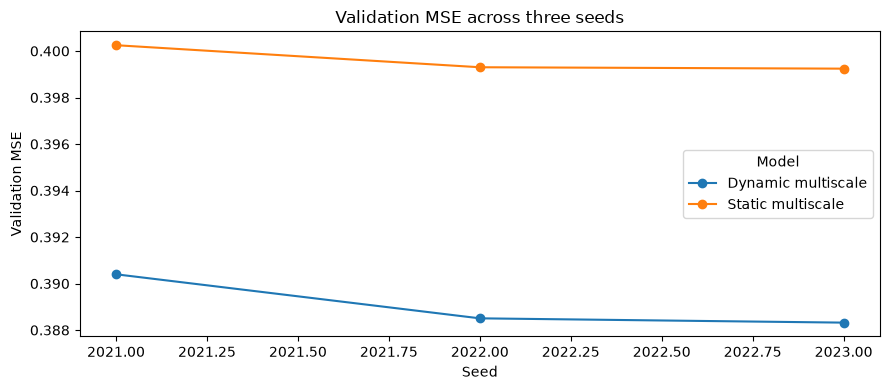

In [6]:
validation_plot = validation.assign(Model=validation["model"].map(FIGURE_NAMES))
axis = validation_plot.pivot(index="seed", columns="Model", values="val_mse").plot(
    marker="o", figsize=(9, 4), ylabel="Validation MSE"
)
axis.set_title("Validation MSE across three seeds")
axis.set_xlabel("Seed")
axis.figure.tight_layout()
axis.figure.savefig(FIGURE_ROOT / "validation_mse_by_seed.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Main test comparison figure

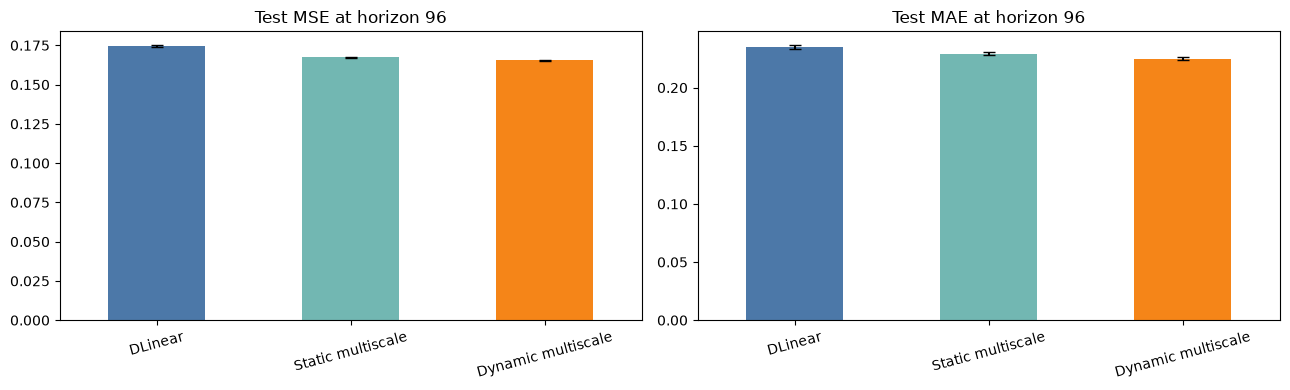

In [7]:
plot_data = test_summary.copy()
plot_data["Model"] = plot_data["model"].map(FIGURE_NAMES)
plot_data = plot_data.set_index("Model")

figure, axes = plt.subplots(1, 2, figsize=(13, 4))
plot_data["test_mse_mean"].plot(
    kind="bar", yerr=plot_data["test_mse_std"], capsize=4, ax=axes[0], color=["#4C78A8", "#72B7B2", "#F58518"]
)
plot_data["test_mae_mean"].plot(
    kind="bar", yerr=plot_data["test_mae_std"], capsize=4, ax=axes[1], color=["#4C78A8", "#72B7B2", "#F58518"]
)
axes[0].set_title("Test MSE at horizon 96")
axes[1].set_title("Test MAE at horizon 96")
for axis in axes:
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=15)
figure.tight_layout()
figure.savefig(FIGURE_ROOT / "main_test_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Multi-horizon results

The final architecture is kept fixed while the forecast horizon changes. The table reports mean and sample standard deviation over the same three seeds.

In [8]:
trained_multihorizon = multihorizon[multihorizon["model"] != "Seasonal naive"].copy()
multi_summary = (
    trained_multihorizon.groupby(["horizon", "model"], as_index=False)
    .agg(
        test_mse_mean=("test_mse", "mean"),
        test_mse_std=("test_mse", "std"),
        test_mae_mean=("test_mae", "mean"),
        test_mae_std=("test_mae", "std"),
    )
)
multi_summary["Model"] = multi_summary["model"].map(DISPLAY_NAMES)
multi_summary["Figure label"] = multi_summary["model"].map(FIGURE_NAMES)
multi_summary.round(6)

,horizon,model,test_mse_mean,test_mse_std,test_mae_mean,test_mae_std,Model,Figure label
0,96,DLinear,0.174638,0.000516,0.234864,0.001741,DLinear reconstruction,DLinear
1,96,Dynamic multiscale V2A,0.165403,0.000455,0.224922,0.001365,Dynamic per-variable multiscale DLinear,Dynamic multiscale
2,192,DLinear,0.215697,0.000286,0.272699,0.000823,DLinear reconstruction,DLinear
3,192,Dynamic multiscale V2A,0.208747,0.000723,0.265370,0.001753,Dynamic per-variable multiscale DLinear,Dynamic multiscale
4,336,DLinear,0.262972,0.001418,0.314450,0.003131,DLinear reconstruction,DLinear
5,336,Dynamic multiscale V2A,0.257300,0.002141,0.308703,0.004215,Dynamic per-variable multiscale DLinear,Dynamic multiscale
6,720,DLinear,0.324445,0.000689,0.362986,0.001255,DLinear reconstruction,DLinear
7,720,Dynamic multiscale V2A,0.319825,0.001091,0.357371,0.001507,Dynamic per-variable multiscale DLinear,Dynamic multiscale


In [9]:
baseline_multi = trained_multihorizon[trained_multihorizon["model"] == "DLinear"]
dynamic_multi = trained_multihorizon[trained_multihorizon["model"] == "Dynamic multiscale V2A"]
paired_multi = baseline_multi.merge(dynamic_multi, on=["horizon", "seed"], suffixes=("_dlinear", "_dynamic"))
paired_multi["mse_reduction_percent"] = 100 * (
    paired_multi["test_mse_dlinear"] - paired_multi["test_mse_dynamic"]
) / paired_multi["test_mse_dlinear"]
paired_multi["mae_reduction_percent"] = 100 * (
    paired_multi["test_mae_dlinear"] - paired_multi["test_mae_dynamic"]
) / paired_multi["test_mae_dlinear"]

multi_improvement = paired_multi.groupby("horizon", as_index=False).agg(
    mse_reduction_mean=("mse_reduction_percent", "mean"),
    mae_reduction_mean=("mae_reduction_percent", "mean"),
    mse_wins=("mse_reduction_percent", lambda values: int((values > 0).sum())),
    mae_wins=("mae_reduction_percent", lambda values: int((values > 0).sum())),
)
multi_improvement.round(3)

,horizon,mse_reduction_mean,mae_reduction_mean,mse_wins,mae_wins
0,96,5.288,4.232,3,3
1,192,3.222,2.688,3,3
2,336,2.158,1.829,3,3
3,720,1.424,1.547,3,3


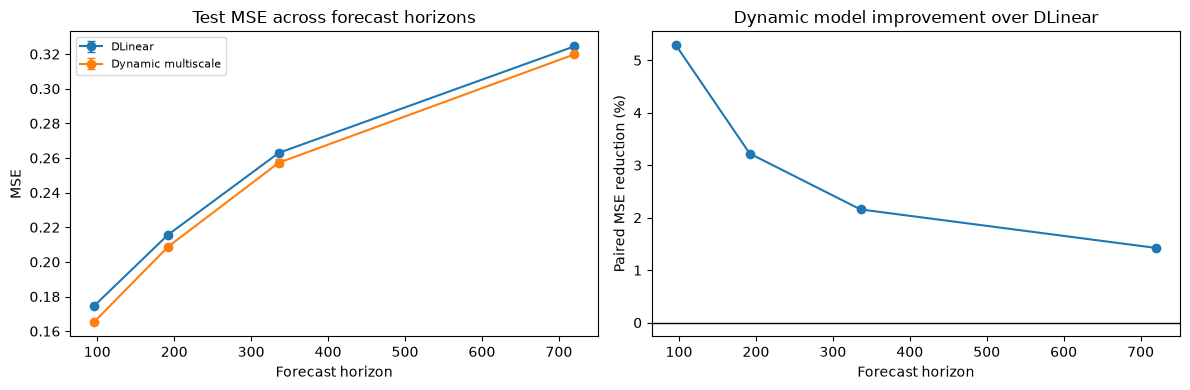

In [10]:
figure, axes = plt.subplots(1, 2, figsize=(12, 4))

for model_name, group in multi_summary.groupby("Figure label"):
    axes[0].errorbar(
        group["horizon"],
        group["test_mse_mean"],
        yerr=group["test_mse_std"],
        marker="o",
        capsize=3,
        label=model_name,
    )
axes[0].set(title="Test MSE across forecast horizons", xlabel="Forecast horizon", ylabel="MSE")
axes[0].legend(fontsize=8)

axes[1].axhline(0, color="black", linewidth=1)
axes[1].plot(multi_improvement["horizon"], multi_improvement["mse_reduction_mean"], marker="o")
axes[1].set(
    title="Dynamic model improvement over DLinear",
    xlabel="Forecast horizon",
    ylabel="Paired MSE reduction (%)",
)

figure.tight_layout()
figure.savefig(FIGURE_ROOT / "multihorizon_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 8. Final interpretation

The seed-2021 reconstruction is within 1.02% MSE and 1.55% MAE of the paper. Static per-variable multiscale DLinear improves over original DLinear, and adapting the scale mixture to each input window improves further. At horizon 96, the dynamic model reduces paired MSE by 5.29% and MAE by 4.23% while adding only 130 parameters. It wins on both metrics for every paired seed at all four horizons. Its largest relative gain occurs at horizon 96, while the benefit becomes smaller for longer forecasts.

Together, these results support a clear conclusion: adaptive multiscale decomposition is a meaningful and consistently beneficial extension of DLinear on the Weather forecasting task. The evidence is limited to one dataset and three seeds, and the extra moving averages increase runtime. The generated figures are saved under `outputs/report_figures/`; the CSV files under `results/` remain the numerical source of truth.